# Graphs

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- Julia setup
- Julia basics
- Julia types and methods

**Outcomes**

- Understand key components of networks/graphs
- Use the Graphs.jl package for working with graphs in Julia
- Implement the breadth-first search algorithm

**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 2

## Introduction

### Why Study Graphs?
- Economic, cultural, political, and social interactions are influenced by *structure* of relationships
  - Transmission of viruses
  - International trade, supply chains, marketplaces
  - Spread of information, diffusion of innovation
  - Political persuasion, localized voting patterns
  - Human behaviors influenced by network of friends (sports, clothes, music)
- Behaviors can be effected by social networks
  - "Influencers"
  - Circles of followers can create echo chambers

### Edges and Nodes

- A **graph** specifies relationships between a collection of items
- Each item is called a **node**
- A relationship between nodes is represented by an **edge**
- Visually, graphs might look like this:

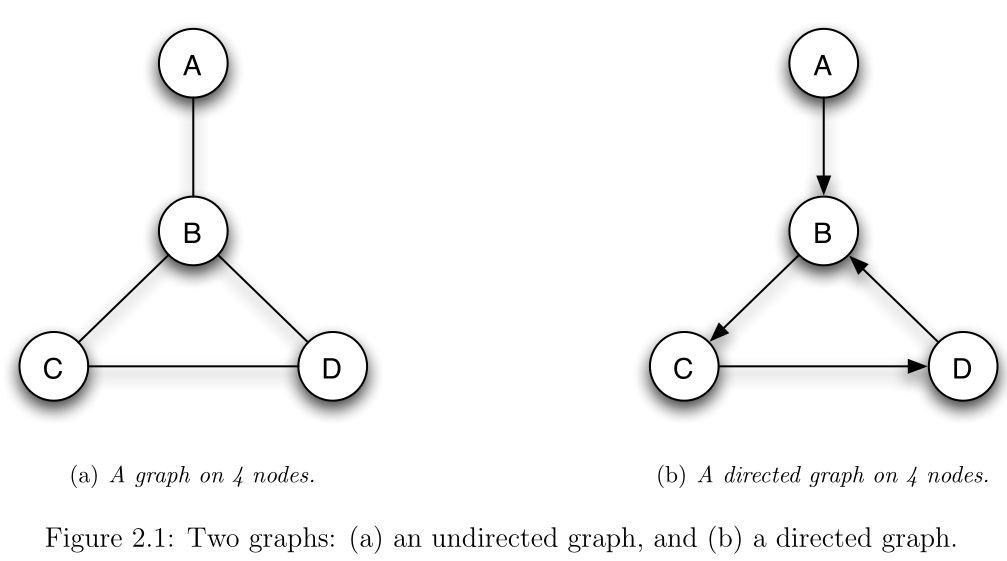

- Here the nodes are `A`, `B`, `C`, `D`
- The edges connect nodes `A-B`, `B-C`, `B-D`, `C-D`

### Adjacency Matrix

- How might we represent the graph above numerically?
- One very common approach is to use a matrix of 0's and 1's called an *adjancency matrix*
- Suppose we have a graph of $N$ nodes
  - Without loss of generality, we'll represent them as integers `1:N`
- Let $A \in \{0,1\}^{N \times N}$ be our adjacency matrix
- Element $A_{ij}$ will be zero unless there is an edge between nodes $i$ and $j$ (diagonal is left as $0$)
- In our above we had
  - Nodes `A`, `B`, `C`, `D` (or 1, 2, 3, 4 respectively)
  - Edges connecting nodes `1-2`, `2-3`, `2-4`, `3-4`
- The adjacency matrix for this example is
$$A = \begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 1 & 1 \\
0 & 1 & 0 & 1 \\
0 & 1 & 1 & 0
\end{bmatrix}$$

## Graphs in Julia

- In Julia there are a few ways we could represent our example graph above
- We could start with the adjacency matrix concept as follows

In [1]:
A = [
	0 1 0 0
	1 0 1 1
	0 1 0 1
	0 1 1 0
]

4×4 Matrix{Int64}:
 0  1  0  0
 1  0  1  1
 0  1  0  1
 0  1  1  0

### Working with Adjacency Matrices

- An adjacency matrix gives us a lot of information about the structure of the graph
- We could compute all of the following
  - Total number of nodes: number of rows or columns of $A$
  - Total number of edges: $\sum_{ij} A_{ij}$
  - Node with most edges: $\text{argmax}_{i} \sum_{j} A_{i,j}$
  - Average number of edges per node: $\frac{2}{N} \cdot \sum_{i,j>i} A_{i,j}$

### Exercise: Adjacency Matrix

- In the cell below we have defined an adjacency matrix called `A_ex1`
- Using `A_ex1` answer the following questions:
  - How many nodes are in the graph?
  - How many edges?
  - Node with most edges (hint, use the `dims` argument to `sum` and then the `argmax` function)
  - Average number of edges per node
  - Number of connections for node 7: $\sum_j A_{j7}$

In [2]:
import Random
Random.seed!(42)

A_ex1 = zeros(Int, 30, 30)

for i in 1:30
    for j in (i+1):30
        if rand() < 0.2
            A_ex1[i, j] = 1
            A_ex1[j, i] = 1
        end
    end
end

In [3]:
# Your code here

ex1_total_nodes = missing
ex1_total_edges = missing
ex1_node_most_edges = missing
ex1_average_edges_per_node = missing
ex1_connections_node_7 = missing

missing

### Graphs.jl

- There are many smart graph theory experts in the Juila community
- They have built a package called Graphs for working with graphs (as well as ancillary pacakges for extra features)
- We can build a `Graphs.Graph` object directly from our adjacency matrix

In [4]:
using Graphs

In [5]:
G1 = Graph(A)

{4, 4} undirected simple Int64 graph

In [6]:
collect(edges(G1))  # collect turns an `iterator` into an array

4-element Vector{Graphs.SimpleGraphs.SimpleEdge{Int64}}:
 Edge 1 => 2
 Edge 2 => 3
 Edge 2 => 4
 Edge 3 => 4

In [7]:
collect(vertices(G1))  # Graphs refers to nodes as `vertices`

4-element Vector{Int64}:
 1
 2
 3
 4

#### Visualizing Graphs

- We can use the GraphPlot package to visualize our graph
- Note that the actual placement of the nodes is randomly generated and then tweaked to clearly show all nodes and edges
- The important thing is *not* the placement of nodes, but rather their *relative structure*

In [8]:
using GraphPlot  # load GraphPlot package

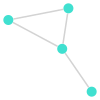

In [9]:
gplot(G1)

### Size considerations

- Using `Array{Int64,2}` to store an adjacency matrix turns out to be a rather costly way to store a graph
- In the original example graph we had 4 nodes and 4 edges
- To store this we needed to have a 4x4 matrix of 64 bit integers
  - This is only (`Int(16 * 64 / 8) == 128`) bytes in our exapmle,
  - But consider a graph of websites and links between them -- that graph would have millions of nodes and edges...
- There are a few approaches to reducing this storage cost:
  - Only store the upper triangle of the matrix
  - Use `Array{Bool,2}` instead of `Array{Int64,2}` to store adjacency matrix ( each element only `sizeof(Bool) == 1` bit!)
  - Use a [SparseMatrix](https://docs.julialang.org/en/v1/stdlib/SparseArrays/)
  - Store as a `Vector{Vector{Int}}`

In [10]:
# Vector{Vector{Int}}
A2 = [[2], [1, 3, 4], [2, 4], [2, 3]]

4-element Vector{Vector{Int64}}:
 [2]
 [1, 3, 4]
 [2, 4]
 [2, 3]

In [11]:
G1.fadjlist

4-element Vector{Vector{Int64}}:
 [2]
 [1, 3, 4]
 [2, 4]
 [2, 3]

## Graph Theory Concepts

- Let's explore some concepts often used in analysis of graphs

### Paths

- When studying graphs it is often natural to ask about how things travel or flow across the graph
- For example, how information spreads amongst a group of friends, how data travels the internet, how diseases are transmitted from one person to another, and how people navigate a metro subway system
- In each of these cases, the flow of things goes from node to node across edges
- A flow from one any node to another node is called a **path**

### Arpanet Example

- Consider the following Graph of the first iteration of the internet

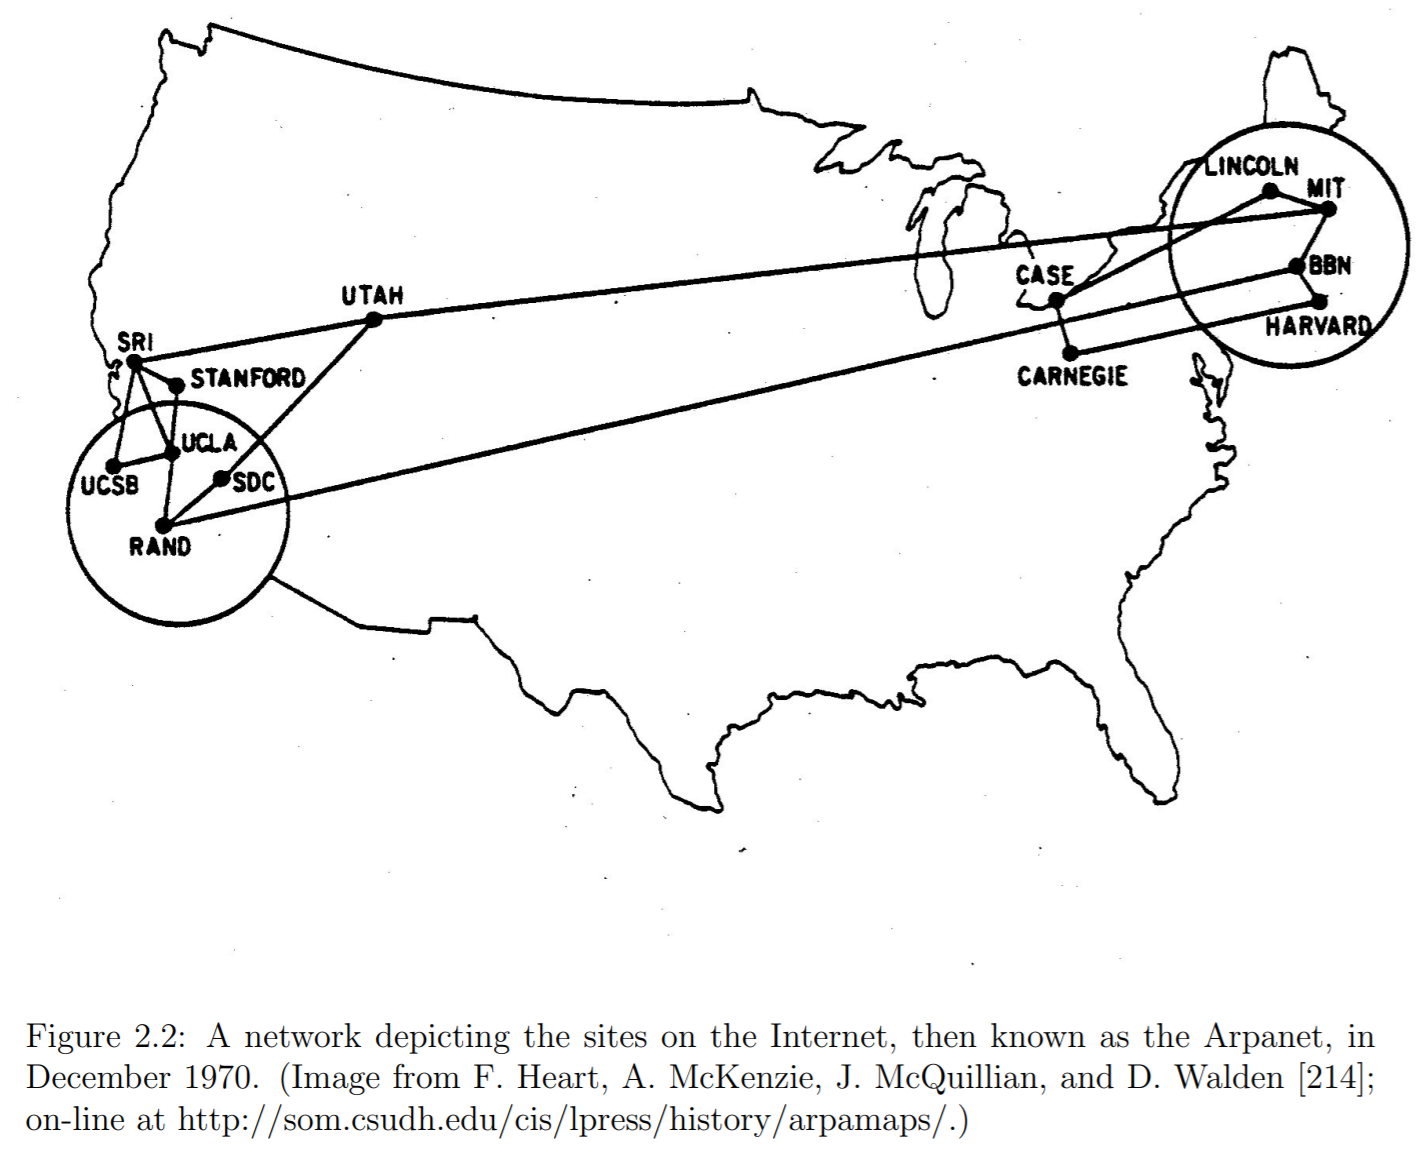

- There are many possible paths through this network
- Consider a path from UCSB to MIT: `UCSB-UCLA-RAND-BBN-MIT`
- Another possible path from UCSB to MIT is `UCSB-SRI-UTAH-MIT`

### Graphs.jl Arpanet

- Let's define the Arpanet using Graphs as it will be helpful throughout this lecture

In [14]:
nodes = [
		"UCSB" => ["SRI", "UCLA"],
		"SRI" => ["UCSB", "UCLA", "STAN", "UTAH"],
		"UCLA" => ["SRI", "UCSB", "STAN", "RAND"],
		"STAN" => ["SRI", "UCLA"],
		"UTAH" => ["SRI", "SDC", "MIT"],
		"SDC" => ["UTAH", "RAND"],
		"RAND" => ["UCLA", "SDC", "BBN"],
		"MIT" => ["UTAH", "BBN", "LINC"],
		"BBN" => ["MIT", "RAND", "HARV"],
		"LINC" => ["MIT", "CASE"],
		"CASE" => ["LINC", "CARN"],
		"CARN" => ["CASE", "HARV"],
		"HARV" => ["CARN", "BBN"]
	]
node_ints = Dict(zip(first.(nodes), 1:length(nodes)))
arpa = SimpleGraph(length(nodes))
for (node, edges) in nodes
    for e in edges
        add_edge!(arpa, node_ints[node], node_ints[e])
    end
end

# save graph for loading in future
savegraph("arpanet.lg", arpa)

1

In [15]:
arpa

{13, 17} undirected simple Int64 graph

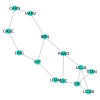

In [16]:
gplot(arpa, nodelabel=first.(nodes))

### Degree

- The **degree** of a node is the number of edges connected to it
- In our example graph G1, node B has degree 3 (connected to A, C, and D)
- Node A has degree 1 (only connected to B)
- Degree is a fundamental measure of node importance in a network
  - High-degree nodes are often called "hubs"
  - In social networks, these might be influential people or "connectors"
- We can compute degree directly from the adjacency matrix
  - Degree of node $i$ is $\sum_j A_{ij}$
- Graphs.jl provides the `degree` function

In [12]:
degree(G1)

4-element Vector{Int64}:
 1
 3
 2
 2

In [13]:
degree(arpa, node_ints["MIT"])

UndefVarError: UndefVarError: `arpa` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

- The degree distribution of a network tells us a lot about its structure
- Many real-world networks have a few high-degree hubs and many low-degree nodes
  - Social networks: celebrities with millions of followers
  - Internet: major websites with many incoming links
  - Transportation: hub airports like Atlanta or Chicago

### Cycles

- An important concept when analyzing graphs is the concept of a cycle
- A cycle is a path that starts and ends at the same node
- For the ARPA net, an example cycle is `LINC-CASE-CARN-HARV-BBN-MIT-LINC`
- Question... what is the shortest possible cycle in a graph (including all endpoints)?
- Cycles appear frequently in real-world networks
  - Friendship networks: if A is friends with B, and B with C, often A and C become friends
  - Transportation networks: cyclical routes allow for redundancy and flexibility
  - Supply chains: cyclical dependencies can create both resilience and vulnerabilities

### Trees

- A **tree** is a connected graph with no cycles
- Trees have exactly N-1 edges for N nodes (the minimum to stay connected)
- Adding any edge to a tree creates a cycle
- Removing any edge from a tree disconnects it
- Trees appear frequently in hierarchical structures
  - Organizational charts: CEO at root, departments as branches
  - Family trees: ancestors and descendants
  - Decision trees: choices branching from initial state
  - File systems: directories and subdirectories
- The breadth-first search we'll see later naturally creates a tree from any graph

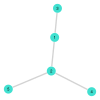

In [17]:
# Example: create a simple tree
tree = SimpleGraph(5)
add_edge!(tree, 1, 2)
add_edge!(tree, 1, 3)
add_edge!(tree, 2, 4)
add_edge!(tree, 2, 5)
gplot(tree, nodelabel=1:5)

In [18]:
is_tree(tree)  # Graphs.jl can check if a graph is a tree

true

In [19]:
is_tree(G1)  # Our original graph has a cycle, so it's not a tree

false

### Connectedness

- A graph is **connected** if there exists a path between every pair of nodes
- In other words, you can travel from any node to any other node by following edges
- The ARPA network was designed to be connected -- ensuring communication between all sites
- We can check if a graph is connected using Graphs.jl

In [20]:
is_connected(arpa)

true

- It is natural to believe that many real-world networks are connected
  - Transportation: you can get to any station
  - Internet: you can visit any website
- But it is entirely possible to have a non-connected graph
  - Social networks (nodes: people, edges: friendships) of college students who different countries
  - Suppliers for a textile company vs a microchip manufacturer

### Distance

- We can extend concept of paths between nodes, to include a notion of distance
- The **length** of a path is the number of steps it takes from beginning to end
  - `MIT-BBN-RAND-UCLA` has length 3 (starting from `MIT` take three steps before ending at `UCLA`)
- The **distance** between two nodes, is the length of the *shortest* path between those nodes
- Graphs can compute distances using the `gdistances` function
- Below we compute the distance between `UCLA` and all nodes

In [21]:
Dict(zip(first.(nodes), gdistances(arpa, node_ints["UCLA"])))

Dict{String, Int64} with 13 entries:
  "HARV" => 3
  "UTAH" => 2
  "UCSB" => 1
  "LINC" => 4
  "RAND" => 1
  "MIT"  => 3
  "CASE" => 5
  "SRI"  => 1
  "STAN" => 1
  "UCLA" => 0
  "SDC"  => 2
  "CARN" => 4
  "BBN"  => 2

## Breadth-First Search

- If asked, how would you go about computing the distance between the `HARV` node and all other nodes?
- One iterative approach might be:
  - Start with `HARV`: note it is distance zero to `HARV`
  - Move on to all nodes directly connected to `HARV`: these are distance 1
  - Then move to all nodes connected to nodes that are distance 1 from `HARV` (excluding any you may have already found): declare these to be at distance 2 from `HARV`
  - Continue traversing edges until you have visited all nodes
- This algorihtm is called **breadth-first search**

### Example: Breadth-First Search from MIT

- The image below shows how breadth-first search would proceed for the MIT node

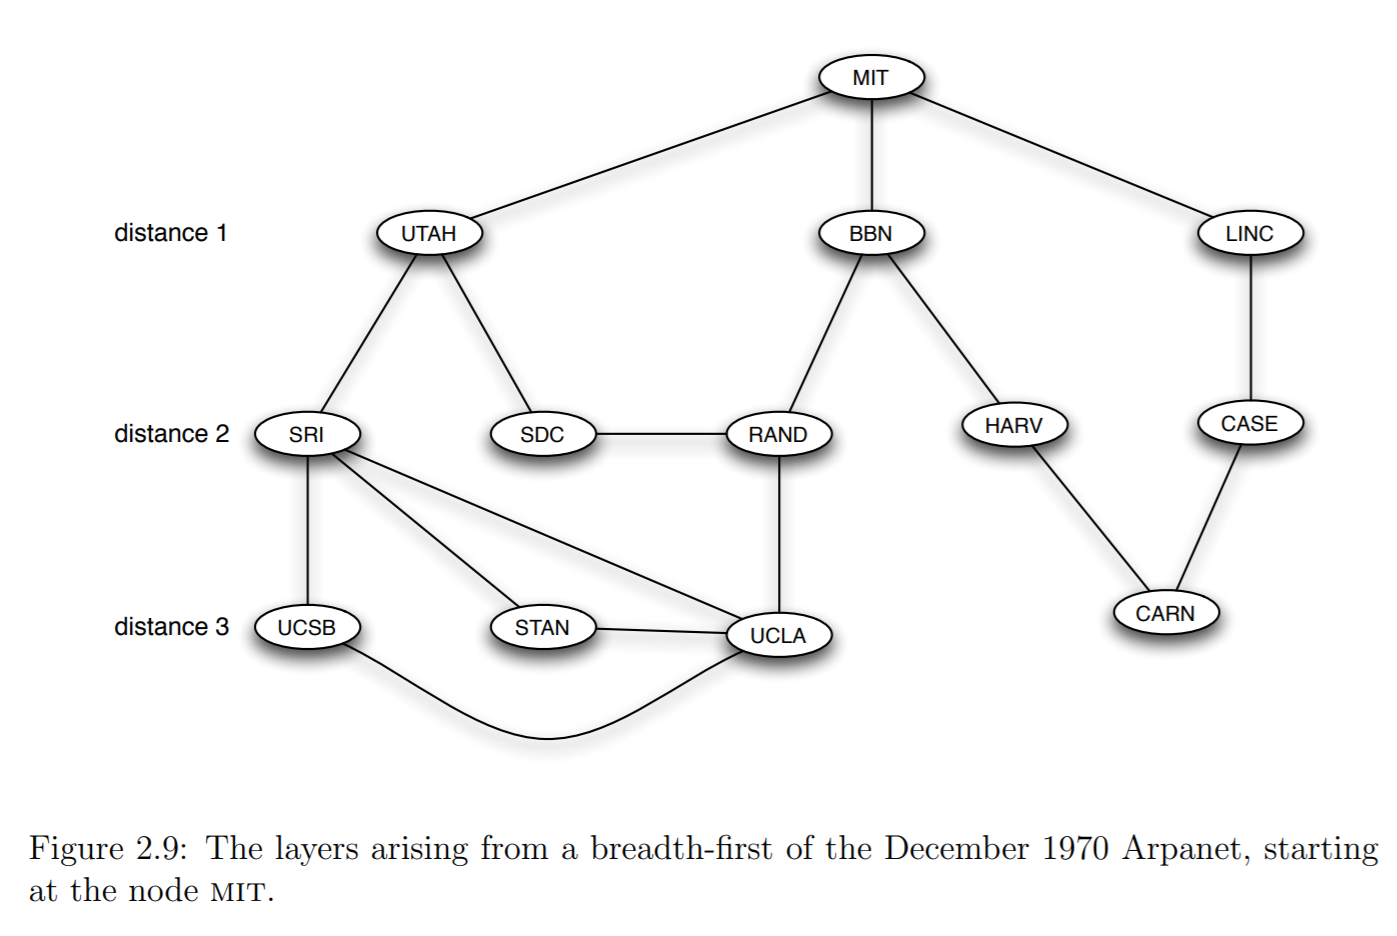

### Exercise (difficult!): BFS

- Now it is time for you to try this out!
- Our goal is to use breadth-first search to compute the distance betwen a given node and all other nodes
- The return value you end up with should be an `Vector{Vector{Int}}`, where element `i` of this vector contains all node labels at distance `i` from the starting node
- Fill in the logic for the `breadth_first_distances` function below

In [22]:
function breadth_first_distances(g, start::Int)
	out = Vector{Int}[]
	# use push!(out, new_nodes) to add to out
	distance = 0

	# TODO: your code here...

	# return out
	out
end

breadth_first_distances (generic function with 1 method)

In [23]:
# Test code

function test_bfd_methods(val, want)
    if length(val) == 0
        error("Make sure to `push!` on to `out` in your function")
    elseif length(val) != maximum(gdistances(arpa, node_ints["HARV"]))
        error("`out` has incorrect number of elements")
    elseif length.(val) != length.(want)
        error("Right number of elements, but not right number in each subvector")
    elseif all(map(x12 -> all(sort(x12[1]) .== sort(x12[2])), zip(val, want)))
        println("correct!")
    end
end

function run_tests()
    val = breadth_first_distances(arpa, node_ints["HARV"])
    want = [[9, 12], [7, 8, 11], [3, 6, 5, 10], [1, 2, 4]]
    test_bfd_methods(val, want)
end

run_tests (generic function with 1 method)

In [24]:
# uncomment the code below and run when you are ready to test your code
# run_tests()

### BFS with Graphs

- The Graphs library contains routines implementing breadth-first search
- The main function is called `bfs_tree`

In [25]:
bfs_carn = bfs_tree(arpa, node_ints["CARN"])

{13, 12} directed simple Int64 graph

- Notice that the printout says we have a graph with 13 nodes, 12 edges and it is a **directed** graph
- Thus far, all graphs we have considered have been undirected
  - We have only been concerned about if a connection (edge) exists between nodes
- A directed graph extends the notion of connecting nodes with a direction
  - We can now say that *things* flow across edges from one node to another -- always in the same direction
- Why would the breadth-first search routine return a directed graph instead of the undirected type we started with?
- Let's visualize it and see if we can understand why

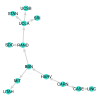

In [26]:
gplot(bfs_carn, nodelabel=first.(nodes))

- Notice that arrows only flow *out* of `CARN`
- They also always flow *away* from `CARN`
- The use of directed edges allows Graphs to represent the shortest path from CARN to any other node
  - For example `STAN`: `CARN -> HARV -> BBN -> RAND -> UCLA -> STAN`

### Exercise: Explore DiGraph

- The `bfs_carn` object has type $(Markdown.Code(string(typeof(bfs_carn))))
- Let's view the names of its properties (properties)

In [27]:
propertynames(bfs_carn)

(:ne, :fadjlist, :badjlist)

In [28]:
bfs_carn.fadjlist

13-element Vector{Vector{Int64}}:
 []
 []
 [1, 2, 4]
 []
 []
 []
 [3, 6]
 [5]
 [7, 8]
 []
 [10]
 [11, 13]
 [9]

- The `fadjlist` (forward adjacency list) property is a `Vector{Vector{Int64}}`
- `fadjlist` has one element per node (call index into outer Vector `i` for node `i`)
- Each element is itself a vector containing node indices for all nodes `j` for which there is an edge flowing from `i` to `j`
-  Below we have set up a new **method** (see below) for the `breadth_first_distances` **function** that takes a `DiGraph` as an argument
- Your task is to implement the the method so that it has the same return value as the previous method from above

In [29]:
function breadth_first_distances(g::SimpleDiGraph, start::Int)
	out = Vector{Int}[]
	# use push!(out, new_nodes) to add to out
	distance = 0

	# TODO: your code here...

	# return out
	out
end

breadth_first_distances (generic function with 2 methods)

In [30]:
# test code
function test_digraph_ex()
	val = breadth_first_distances(
		bfs_tree(arpa, node_ints["HARV"]),
		node_ints["HARV"]
	)
	want = [[9, 12], [7, 8, 11], [3, 6, 5, 10], [1, 2, 4]]
	test_bfd_methods(val, want)
end

test_digraph_ex (generic function with 1 method)

In [31]:
# uncomment the code below when you are ready to test your code!
# test_digraph_ex()

## Components

- A *component* of a graph is a self-contained subset of the nodes
- More precisely, a set of nodes is a component if
  1. Every node in the subset has a path to every other node in the subset
  2. The subset is not part of a larger set with property (1)
- Example:

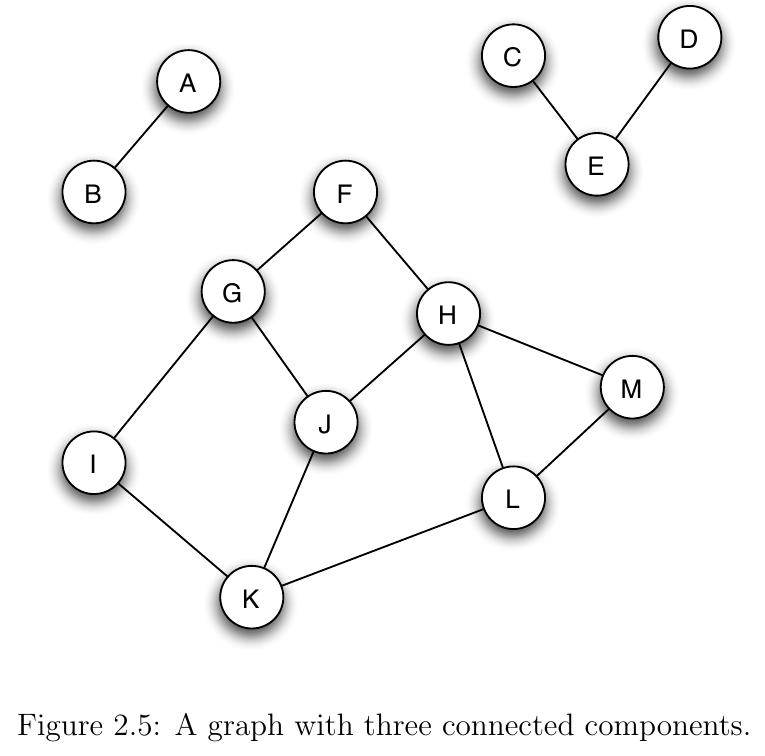

### Finding Components

- Graphs.jl provides functions to identify and work with components
- `connected_components(g)` returns a vector of vectors, where each inner vector contains the nodes in one component
- Let's create a graph with multiple components and explore it

In [32]:
# Create a graph with three components
multi_component = SimpleGraph(10)
# Component 1: nodes 1, 2, 3
add_edge!(multi_component, 1, 2)
add_edge!(multi_component, 2, 3)
add_edge!(multi_component, 3, 1)
# Component 2: nodes 4, 5, 6, 7
add_edge!(multi_component, 4, 5)
add_edge!(multi_component, 5, 6)
add_edge!(multi_component, 6, 7)
add_edge!(multi_component, 7, 4)
# Component 3: nodes 8, 9
add_edge!(multi_component, 8, 9)
# Node 10 is isolated (its own component)

true

In [33]:
components = connected_components(multi_component)

4-element Vector{Vector{Int64}}:
 [1, 2, 3]
 [4, 5, 6, 7]
 [8, 9]
 [10]

In [34]:
println("Number of components: ", length(components))
for (i, comp) in enumerate(components)
    println("Component $i has $(length(comp)) nodes: $comp")
end

Number of components: 4
Component 1 has 3 nodes: [1, 2, 3]
Component 2 has 4 nodes: [4, 5, 6, 7]
Component 3 has 2 nodes: [8, 9]
Component 4 has 1 nodes: [10]


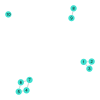

In [35]:
gplot(multi_component, nodelabel=1:10)

### Why Components Matter

- Components help us understand the structure of social networks
- Each component represents a group that can communicate internally but not with other groups
- In social network analysis, components reveal:
  - **Information silos**: Ideas spread within components but not between them
  - **Echo chambers**: Opinions reinforce within isolated groups
  - **Community detection**: Natural groupings in social structures
  - **Influence boundaries**: Limits of where influence can spread

### Real-World Implications

- **Disease spread**: Each component represents a boundary for transmission
  - COVID-19 travel restrictions aimed to keep countries as separate components
  - Contact tracing identifies components to contain outbreaks
- **Marketing**: Products spread through word-of-mouth within components
  - Need to seed each component separately for full market penetration
  - Viral marketing campaigns can fail if they don't bridge components
- **Political polarization**: Separate components in social media
  - Different groups may never see opposing viewpoints
  - Bridging nodes between components become crucial for dialogue
- **Infrastructure resilience**: Power grids, internet backbone
  - Multiple components mean system fragmentation after failures
  - Redundant connections prevent network from splitting into components

### Giant Component

- Many real-world networks have a **giant component** containing most nodes
- Plus several small components or isolated nodes
- Let's check if ARPANET has this structure

In [36]:
arpa_components = connected_components(arpa)
println("ARPANET has $(length(arpa_components)) component(s)")
println("Component sizes: ", length.(arpa_components))

ARPANET has 1 component(s)
Component sizes: [13]


- ARPANET is fully connected (one component) by design
- This ensures any site can communicate with any other site
- Network resilience was a key design goal for the early internet

## Example

- How many components are in this graph?

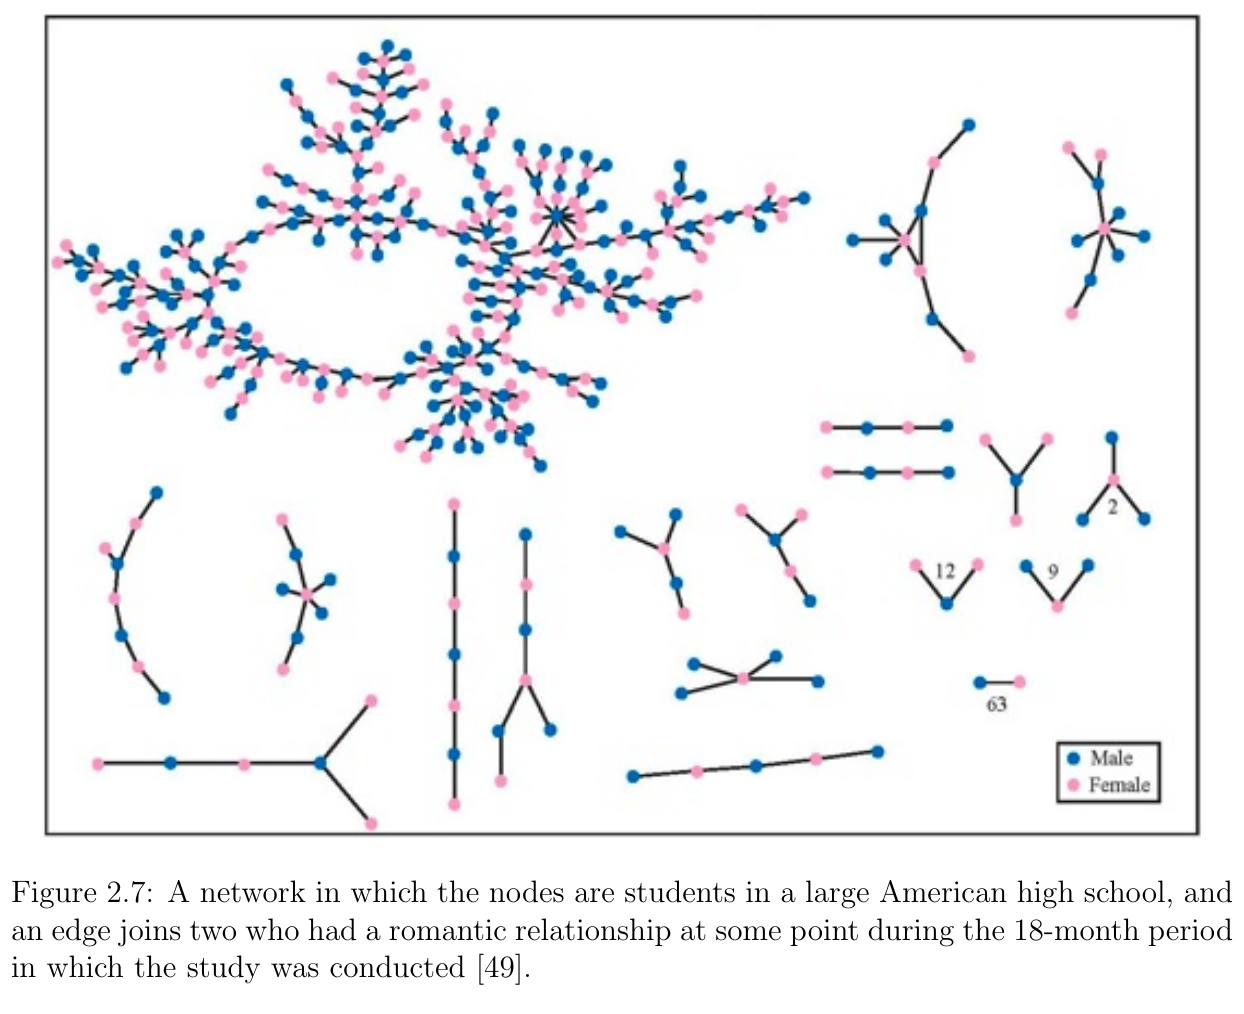

## Real-World Network Examples

- Let's analyze some actual network datasets to see these concepts in practice
- We'll look at:
  - Zachary's Karate Club: A classic social network dataset
  - Facebook ego networks: Social connections from real Facebook data
  - Email networks: Communication patterns in organizations

### Zachary's Karate Club

- Famous dataset from sociology (Zachary, 1977)
- Documents friendships in a karate club that split into two factions
- 34 members (nodes), 78 friendships (edges)
- Perfect for studying community structure and components

In [37]:
# Graphs.jl includes several famous networks as built-in datasets!
karate = smallgraph(:karate)

{34, 78} undirected simple Int64 graph

In [38]:
# Analyze the karate club network
using Statistics  # for `mean` function
println("Karate Club Network:")
println("  Nodes: ", nv(karate))
println("  Edges: ", ne(karate))
println("  Average degree: ", round(mean(degree(karate)), digits=2))
println("  Is connected: ", is_connected(karate))

Karate Club Network:
  Nodes: 34
  Edges: 78
  Average degree: 4.59
  Is connected: true


In [39]:
# Look at degree distribution
degrees = degree(karate)
println("\nDegree distribution:")
println("  Min degree: ", minimum(degrees))
println("  Max degree: ", maximum(degrees))
println("  Node with most connections: ", argmax(degrees))


Degree distribution:
  Min degree: 1
  Max degree: 17
  Node with most connections: 34


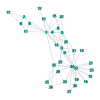

In [40]:
# Visualize the karate club network
gplot(karate, nodelabel=1:nv(karate), nodesize=0.1)

### Exercise: Analyzing the Petersen Graph

- The Petersen graph is a famous graph in graph theory
- It appears in many theoretical results and counterexamples
- Your task: analyze this network's structure

In [41]:
# Load the Petersen graph
petersen = smallgraph(:petersen)

# TODO: Calculate the following properties
num_nodes = missing           # Total number of nodes
num_edges = missing           # Total number of edges
avg_degree = missing          # Average degree (should be the same for all nodes!)
is_it_connected = missing     # Is the graph connected?
is_it_tree = missing          # Is it a tree?
num_components = missing      # How many components?

# Print your results
println("Petersen Graph Analysis:")
println("  Number of nodes: ", num_nodes)
println("  Number of edges: ", num_edges)
println("  Average degree: ", avg_degree)
println("  Is connected: ", is_it_connected)
println("  Is it a tree: ", is_it_tree)
println("  Number of components: ", num_components)

Petersen Graph Analysis:
  Number of nodes: missing
  Number of edges: missing
  Average degree: missing
  Is connected: missing
  Is it a tree: missing
  Number of components: missing


### Other Built-in Networks

- Graphs.jl includes many classic networks for teaching and research
- Some interesting examples you can explore:

In [42]:
# Examples of other built-in graphs
graphs_to_explore = [
    :house,        # The "house" graph (5 nodes)
    :bull,         # The bull graph
    :cubical,      # 3-dimensional cube
    :diamond,      # Diamond graph
    :dodecahedral, # Dodecahedron graph (20 nodes)
    :heawood,      # Heawood graph (14 nodes)
    :moebiuskantor,# Möbius-Kantor graph
    :octahedral,   # Octahedron graph
    :pappus,       # Pappus graph
    :tutte,        # Tutte graph (46 nodes)
]

# Try loading and analyzing one!
# Example: g = smallgraph(:house)

10-element Vector{Symbol}:
 :house
 :bull
 :cubical
 :diamond
 :dodecahedral
 :heawood
 :moebiuskantor
 :octahedral
 :pappus
 :tutte